# Grounding Test
This notebook is dedicated to testing the visual grounding capabilities of the C-RADIOv4-SO400M model on egocentric assembly frames.

## Phase 0.1: Model Loading and VRAM Sanity Check
In this section, we initialize the model from local weights, perform a forward pass on a single raw frame, and reshape the output spatial features into a 2D grid.

In [1]:
import torch
import os
import tkinter as tk
from tkinter import filedialog
from PIL import Image
from transformers import AutoModel, CLIPImageProcessor
from einops import rearrange
import time

print("Loading the model (this might take a few seconds)...")

# 1. Point to the local directory where we downloaded the weights
local_repo = "../models/c_radio_weights"

# 2. Load the processor and the model into VRAM
image_processor = CLIPImageProcessor.from_pretrained(local_repo)
model = AutoModel.from_pretrained(local_repo, trust_remote_code=True)
model.eval().cuda() # Move the model to the GPU

print("Model successfully loaded into VRAM!\n")

# 3. Choose the frame using a File Explorer dialog
# Initialize tkinter and hide the main window
root = tk.Tk()
root.attributes('-topmost', True) # Bring the dialog to the front
root.withdraw()

# Open the file explorer starting from the default directory
image_path = filedialog.askopenfilename(
    initialdir=os.path.abspath("../data/extracted_frames/"),
    title="Select a frame for testing",
    filetypes=(("JPEG files", "*.jpg"), ("All files", "*.*"))
)

root.destroy() # Close the tkinter instance

# Safety check if the user clicks "Cancel"
if not image_path:
    raise ValueError("No file was selected. Please run the cell again.")

print(f"\nLoading image from: {image_path}")
image = Image.open(image_path).convert('RGB')

# 4. Image preprocessing
pixel_values = image_processor(images=image, return_tensors='pt', do_resize=True).pixel_values
pixel_values = pixel_values.cuda()

print(f"Input image tensor shape: {pixel_values.shape}")

# 5. Inference (Memory critical phase)
print("Starting inference...")
start_time = time.time()

# Using torch.no_grad() is vital to prevent allocating memory for training
with torch.no_grad():
    # C-RADIOv4 returns two tensors: a global summary and dense spatial features
    summary, spatial_features = model(pixel_values)

# 6. Reshape the spatial features
# The patch size of C-RADIO is 16. We use einops to convert the 1D tensor back to a 2D grid (B, D, H, W)
patch_size = 16
h = pixel_values.shape[-2] // patch_size
w = pixel_values.shape[-1] // patch_size
spatial_features_2d = rearrange(spatial_features, 'b (h w) d -> b d h w', h=h, w=w)

end_time = time.time()

# 7. Results
print("\n--- TEST SUCCESSFULLY COMPLETED ---")
print(f"Local inference time: {end_time - start_time:.4f} seconds")
print(f"Summary Token shape (Global concept): {summary.shape}")
print(f"Spatial Features shape (Dense 2D grid): {spatial_features_2d.shape}")

Loading the model (this might take a few seconds)...


Loading weights:   0%|          | 0/330 [00:00<?, ?it/s]

Model successfully loaded into VRAM!


Loading image from: C:/Users/ADV/Universita/Magistrale/Tesi/vad-project/data/extracted_frames/1_disassembled_controlled_caos_f0001.jpg
Input image tensor shape: torch.Size([1, 3, 512, 512])
Starting inference...

--- TEST SUCCESSFULLY COMPLETED ---
Local inference time: 0.2987 seconds
Summary Token shape (Global concept): torch.Size([1, 2304])
Spatial Features shape (Dense 2D grid): torch.Size([1, 1152, 32, 32])


## Phase 0.1.5: Unsupervised Semantic Feature Visualization (PCA)

This section reduces the dense 1152-dimensional spatial features using PCA and plots them as an RGB semantic map alongside the original image. 

Running PCA to visualize semantic features...


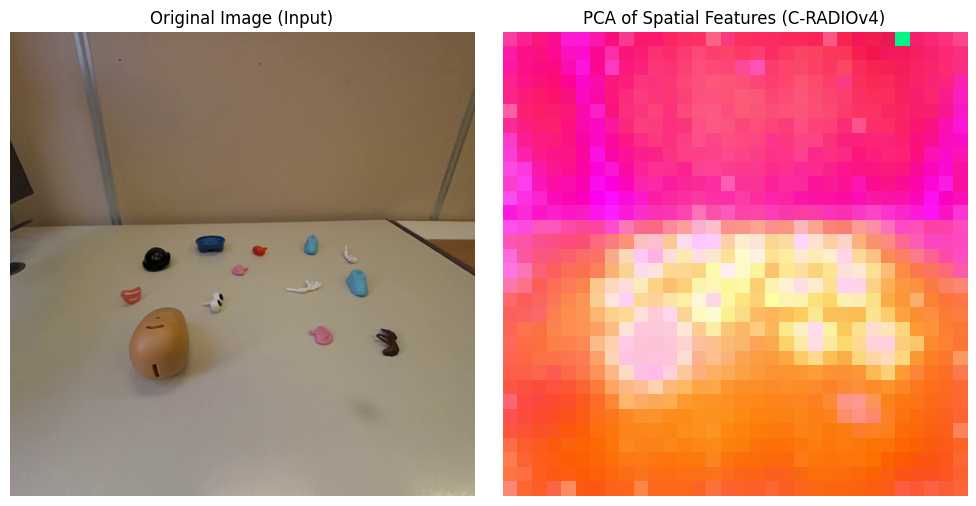

In [4]:
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
import numpy as np

print("Running PCA to visualize semantic features...")

# 1. Remove the batch dimension from the 2D features [1, 1152, 32, 32] -> [1152, 32, 32]
features_np = spatial_features_2d[0].cpu().numpy()

# 2. Flatten spatial dimensions for PCA -> [1024, 1152] (1024 pixels, 1152 features)
features_flat = features_np.reshape(features_np.shape[0], -1).T 

# 3. Reduce from 1152 dimensions down to 3 dimensions (RGB)
pca = PCA(n_components=3)
pca_features = pca.fit_transform(features_flat)

# 4. Normalize values between 0 and 1 to plot them as RGB colors
pca_features_norm = (pca_features - pca_features.min(0)) / (pca_features.max(0) - pca_features.min(0))

# 5. Reshape back to the 32x32 grid -> [32, 32, 3]
pca_img = pca_features_norm.reshape(32, 32, 3)

# 6. Plot the results!
fig, axes = plt.subplots(1, 2, figsize=(10, 5))

# Original image (resized for comparison)
axes[0].imshow(image.resize((512, 512)))
axes[0].set_title("Original Image (Input)")
axes[0].axis('off')

# PCA map of the features
axes[1].imshow(pca_img)
axes[1].set_title("PCA of Spatial Features (C-RADIOv4)")
axes[1].axis('off')

plt.tight_layout()
plt.show()

## Phase 0.2: Language-Guided Semantic Grounding

In this section, we load the `visual_dictionary.json` containing the physical descriptions of the assembly parts. We encode these text prompts using the model's text encoder and compute the cosine similarity against the 2D spatial feature grid extracted in Phase 0.1. Finally, we upsample the resulting heatmaps, apply a threshold to isolate the highest activations, and extract bounding boxes for each component to verify the model's grounding accuracy.

[transformers] Model config: bos_token_id must be `None` or an integer within the vocabulary (between 0 and 31999), got 49406. This may result in unexpected behavior.
[transformers] Model config: eos_token_id must be `None` or an integer within the vocabulary (between 0 and 31999), got 49407. This may result in unexpected behavior.


Starting Phase 0.2: Language-Guided Grounding (Softmax Corrected)...
Loaded 11 components + 1 background noise class.


Loading weights:   0%|          | 0/888 [00:00<?, ?it/s]

Extracting text embeddings and computing similarities...


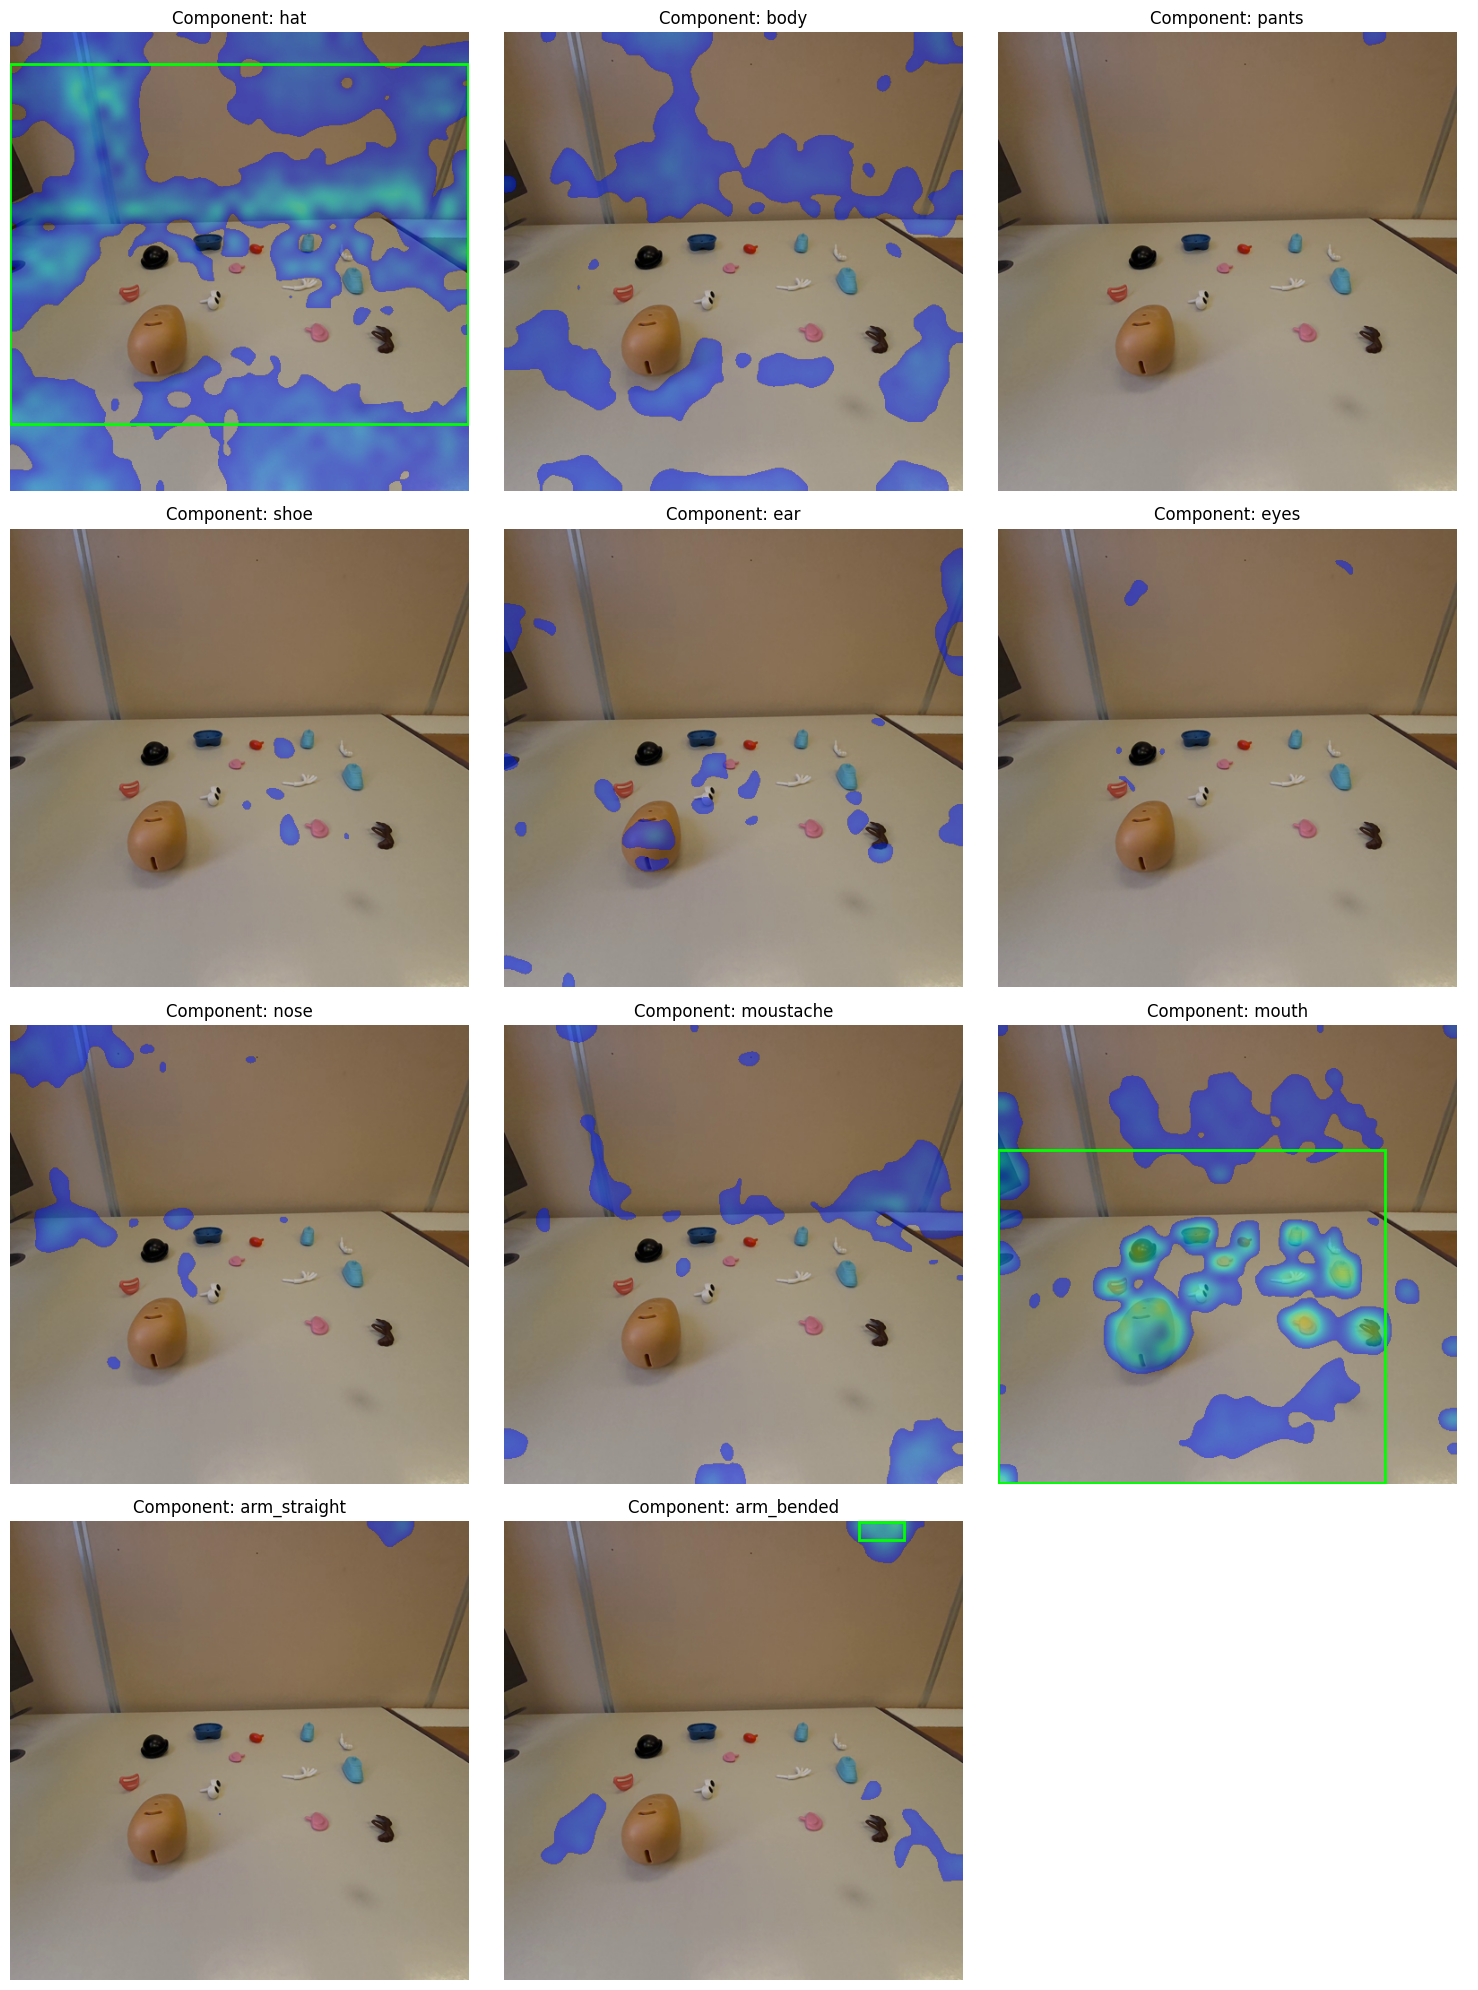

Grounding Visualization with Softmax Complete!


In [ ]:
import json
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import numpy as np
from transformers import AutoTokenizer, AutoModel

print("Starting Phase 0.2: Language-Guided Grounding (Absolute Cosine Similarity)...")

# 1. Load the Visual Dictionary
dict_path = '../configs/visual_dictionary.json'
with open(dict_path, 'r') as f:
    visual_dict = json.load(f)

prompt_template = "a photo of a {}"
part_names = list(visual_dict.keys())
prompts = [prompt_template.format(desc) for desc in visual_dict.values()]

print(f"Loaded {len(part_names)} components.")

# 2. Load Tokenizer and Text Model (SigLIP)
siglip_repo = "google/siglip-so400m-patch14-384"
tokenizer = AutoTokenizer.from_pretrained(siglip_repo)
siglip_model = AutoModel.from_pretrained(siglip_repo).eval().to('cuda')
inputs = tokenizer(prompts, padding=True, return_tensors="pt").to('cuda')

# 3. Extract Text Embeddings and Normalize Features
print("Extracting text embeddings and computing similarities...")
with torch.no_grad():
    text_outputs = siglip_model.get_text_features(**inputs)
    
    # Safely extract the raw tensor
    if hasattr(text_outputs, 'pooler_output'):
        text_features = text_outputs.pooler_output
    elif hasattr(text_outputs, 'text_embeds'):
        text_features = text_outputs.text_embeds
    else:
        text_features = text_outputs
        
    text_norm = text_features / text_features.norm(p=2, dim=-1, keepdim=True)
    spatial_norm = spatial_features_2d / spatial_features_2d.norm(p=2, dim=1, keepdim=True)

# 4. Compute RAW Cosine Similarity [-1 to 1] (No Softmax!)
similarity_maps = torch.einsum('bdhw,nd->nhw', spatial_norm, text_norm)

# 5. Upsample the Similarity Maps
similarity_maps = similarity_maps.unsqueeze(1)
heatmaps_up = F.interpolate(similarity_maps, size=(512, 512), mode='bicubic', align_corners=False)
heatmaps_up = heatmaps_up.squeeze(1).cpu().numpy()

# 6. Visualization and Smart Thresholding
cols = 3
rows = (len(part_names) + cols - 1) // cols
fig, axes = plt.subplots(rows, cols, figsize=(15, 5 * rows))
axes = axes.flatten()

for i, name in enumerate(part_names):
    ax = axes[i]
    heatmap = heatmaps_up[i]
    max_sim = heatmap.max()
    
    ax.imshow(image.resize((512, 512)))
    
    # Fixed absolute boundaries prevent the "mirage" effect of min-max scaling
    im = ax.imshow(heatmap, cmap='jet', alpha=0.5, vmin=0.15, vmax=0.30)
    
    # Draw Bounding Box ONLY if the model is confident the object exists (sim > 0.22)
    if max_sim > 0.22:
        # Find the core of the activation
        threshold = np.percentile(heatmap[heatmap > 0.20], 95) if (heatmap > 0.20).any() else max_sim * 0.95
        y_indices, x_indices = np.where(heatmap >= threshold)
        
        if len(x_indices) > 0 and len(y_indices) > 0:
            x_min, x_max = x_indices.min(), x_indices.max()
            y_min, y_max = y_indices.min(), y_indices.max()
            
            rect = patches.Rectangle((x_min, y_min), x_max - x_min, y_max - y_min, 
                                     linewidth=2, edgecolor='lime', facecolor='none')
            ax.add_patch(rect)
            
    ax.set_title(f"Component: {name} | Max Sim: {max_sim:.2f}")
    ax.axis('off')

for j in range(len(part_names), len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.show()
print("Grounding Visualization Complete!")